# PAC-max sweep results

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import gymnasium as gym

PROJECT = Path.cwd()
sys.path.insert(0, str(PROJECT / "scripts"))

import load_results as lr   # sacred runs -> long DataFrame, one row per (run, timestep)
import plotting as pl       # long DataFrame -> one panel per call

import matrix_envs  # registers the env ids; also lets us read each game's true optimum

ALG = "pac_sarsa_max_ns"  # sacred results dir (the --config name is pac_max_ns)

# seed -> label. 0-2 predate the SoftPoliciesSelector greedy-eval fix (test_mode
# was ignored, so "greedy" evaluation was still stochastic sampling); 3-5 were
# trained with the fix in place, same q_nstep=10; 6-8 (LBF only, run manually
# with q_nstep=5) additionally drop q_nstep from 10 to 5, per the paper's own
# N-step ablation recommendation for LBF (Section 4.5).
GROUP_ORDER = ["pre_fix_q10", "post_fix_q10", "post_fix_q5"]
GROUP_LABELS = {
    "pre_fix_q10": "pre-fix, q_nstep=10 — NOT greedy (sampled instead of argmax)",
    "post_fix_q10": "post-fix, q_nstep=10 — greedy eval",
    "post_fix_q5": "post-fix, q_nstep=5 — greedy eval (LBF-only n-step ablation)",
}

## Load results — one row per (run, evaluation point)

In [2]:
df = lr.load_runs(["test_return_mean"], algs=ALG, config_keys=["q_nstep"])
df["group"] = np.where(df["seed"] <= 2, "pre_fix_q10",
                       "post_fix_q" + df["q_nstep"].astype(str))

envs = sorted(df["env"].unique())
runs = df.drop_duplicates(lr.RUN_KEYS)
print(f"{len(runs)} runs loaded across {len(envs)} envs, by group:")
print(runs["group"].value_counts().reindex(GROUP_ORDER).dropna().astype(int))
df.head(3)

60 runs loaded across 11 envs, by group:
group
pre_fix_q10     33
post_fix_q10    21
post_fix_q5      6
Name: count, dtype: int64


,alg,env,seed,run,t,test_return_mean,status,duration_s,q_nstep,group
0,pac_sarsa_max_ns,lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0,0,2,250,-0.405,COMPLETED,4551.366249,10,pre_fix_q10
1,pac_sarsa_max_ns,lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0,0,2,140461,-0.355,COMPLETED,4551.366249,10,pre_fix_q10
2,pac_sarsa_max_ns,lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0,0,2,280578,-0.390,COMPLETED,4551.366249,10,pre_fix_q10


## Per-environment training curves

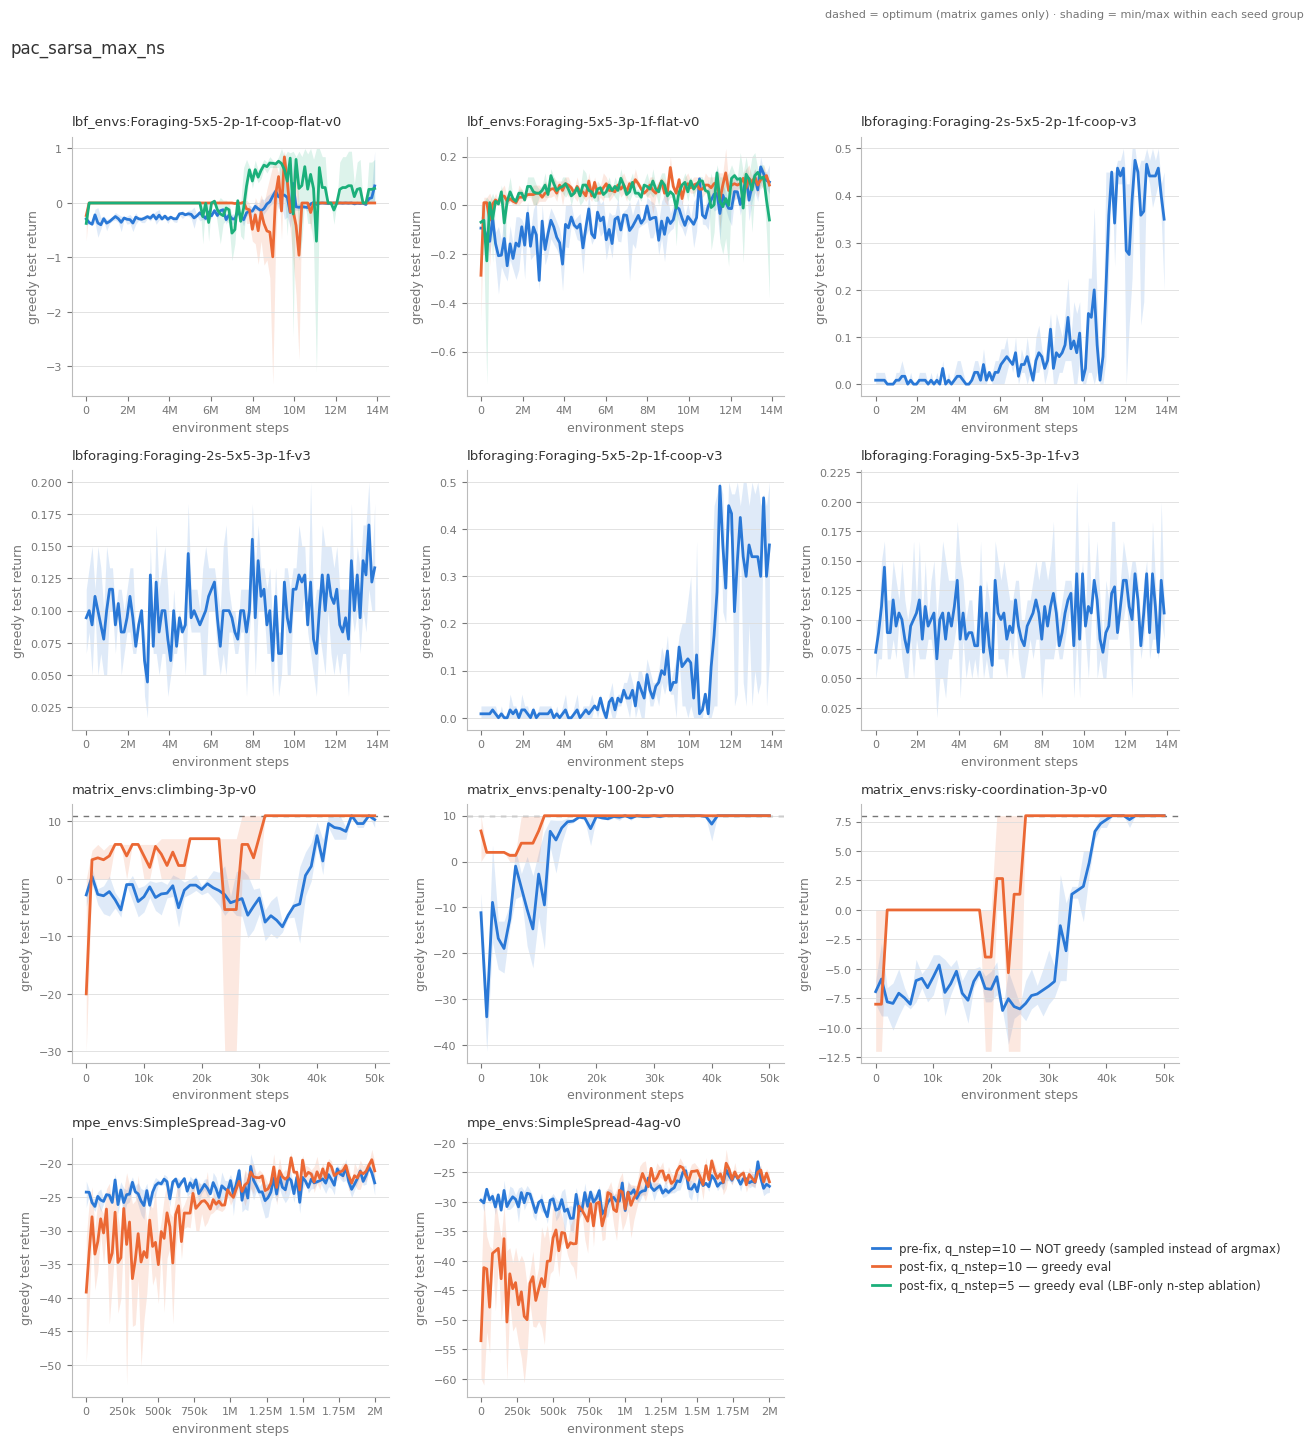

In [3]:
def game_optimum(env):
    """True value of the best joint action, for matrix games only."""
    kwargs = dict(gym.spec(env.split(":")[-1]).kwargs)  # ids are registered unprefixed
    kwargs.pop("deterministic", None)
    return kwargs.pop("game_fn")(**kwargs).common_table().max()


fig, axes = pl.grid(len(envs), ncols=3)
for ax, env in zip(axes, envs):
    if env.startswith("matrix_envs:"):
        pl.reference_line(ax, game_optimum(env))
    pl.panel(df[df["env"] == env], y="test_return_mean", hue="group",
             order=GROUP_ORDER, labels=GROUP_LABELS, ax=ax,
             title=env, ylabel="greedy test return")

# built from GROUP_ORDER rather than from the panels, so the legend lists all
# three groups even though post_fix_q5 only ever has data on the LBF panels
pl.legend(fig, order=GROUP_ORDER, labels=GROUP_LABELS)
pl.finish(fig, suptitle=ALG,
          note="dashed = optimum (matrix games only) · shading = min/max within each seed group")

## Final return summary

Mean and std (over the seeds in each group) of the last greedy test-return point.

In [4]:
lr.final_values(df, ["test_return_mean"], by=("env", "group")).round(3)

test_return_mean         \
                                                                  mean    std   
env                                      group                                  
lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0 post_fix_q10            0.000  0.000   
                                         post_fix_q5             0.267  0.462   
                                         pre_fix_q10             0.313  0.556   
lbf_envs:Foraging-5x5-3p-1f-flat-v0      post_fix_q10            0.083  0.029   
                                         post_fix_q5            -0.060  0.277   
                                         pre_fix_q10             0.096  0.063   
lbforaging:Foraging-2s-5x5-2p-1f-coop-v3 pre_fix_q10             0.350  0.132   
lbforaging:Foraging-2s-5x5-3p-1f-v3      pre_fix_q10             0.133  0.044   
lbforaging:Foraging-5x5-2p-1f-coop-v3    pre_fix_q10             0.367  0.210   
lbforaging:Foraging-5x5-3p-1f-v3         pre_fix_q10             0.106  0.019   
matrix_envs:climbing-3p-v0               post_fix_q10           11.000  0.000   
                                         pre_fix_q10            10.317  1.184   
matrix_envs:penalty-100-2p-v0            post_fix_q10           10.000  0.000   
                                         pre_fix_q10            10.000  0.000   
matrix_envs:risky-coordination-3p-v0     post_fix_q10            8.000  0.000   
                                         pre_fix_q10             8.000  0.000   
mpe_envs:SimpleSpread-3ag-v0             post_fix_q10          -21.094  2.057   
                                         pre_fix_q10           -22.880  1.613   
mpe_envs:SimpleSpread-4ag-v0             post_fix_q10          -26.594  1.510   
                                         pre_fix_q10           -27.358  0.933   

                                                      runs  
                                                            
env                                      group              
lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0 post_fix_q10    3  
                                         post_fix_q5     3  
                                         pre_fix_q10     3  
lbf_envs:Foraging-5x5-3p-1f-flat-v0      post_fix_q10    3  
                                         post_fix_q5     3  
                                         pre_fix_q10     3  
lbforaging:Foraging-2s-5x5-2p-1f-coop-v3 pre_fix_q10     3  
lbforaging:Foraging-2s-5x5-3p-1f-v3      pre_fix_q10     3  
lbforaging:Foraging-5x5-2p-1f-coop-v3    pre_fix_q10     3  
lbforaging:Foraging-5x5-3p-1f-v3         pre_fix_q10     3  
matrix_envs:climbing-3p-v0               post_fix_q10    3  
                                         pre_fix_q10     3  
matrix_envs:penalty-100-2p-v0            post_fix_q10    3  
                                         pre_fix_q10     3  
matrix_envs:risky-coordination-3p-v0     post_fix_q10    3  
                                         pre_fix_q10     3  
mpe_envs:SimpleSpread-3ag-v0             post_fix_q10    3  
                                         pre_fix_q10     3  
mpe_envs:SimpleSpread-4ag-v0             post_fix_q10    3  
                                         pre_fix_q10     3

# Max Critic Error

In [5]:
MAX_CRITIC_KEYS = [
    "max_critic_pred_error",
    "max_critic_bias",
    "sampled_max_bias",
    "max_critic_loss",
    "max_critic_grad_norm",
]

mc = lr.load_runs(MAX_CRITIC_KEYS, algs=ALG, config_keys=["q_nstep"], skip_missing=True)
mc["group"] = np.where(mc["seed"] <= 2, "pre_fix_q10",
                       "post_fix_q" + mc["q_nstep"].astype(str))
logged = [k for k in MAX_CRITIC_KEYS if k in mc.columns]
print(f"logged by these runs: {logged}")
mc.head(3)

logged by these runs: ['max_critic_pred_error', 'max_critic_loss', 'max_critic_grad_norm']


,alg,env,seed,run,t,max_critic_pred_error,max_critic_loss,max_critic_grad_norm,status,duration_s,q_nstep,group
0,pac_sarsa_max_ns,lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0,0,2,250,0.370532,0.217969,3.701463,COMPLETED,4551.366249,10,pre_fix_q10
1,pac_sarsa_max_ns,lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0,0,2,140461,0.026859,0.001237,0.057182,COMPLETED,4551.366249,10,pre_fix_q10
2,pac_sarsa_max_ns,lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0,0,2,280578,0.026868,0.001162,0.026361,COMPLETED,4551.366249,10,pre_fix_q10


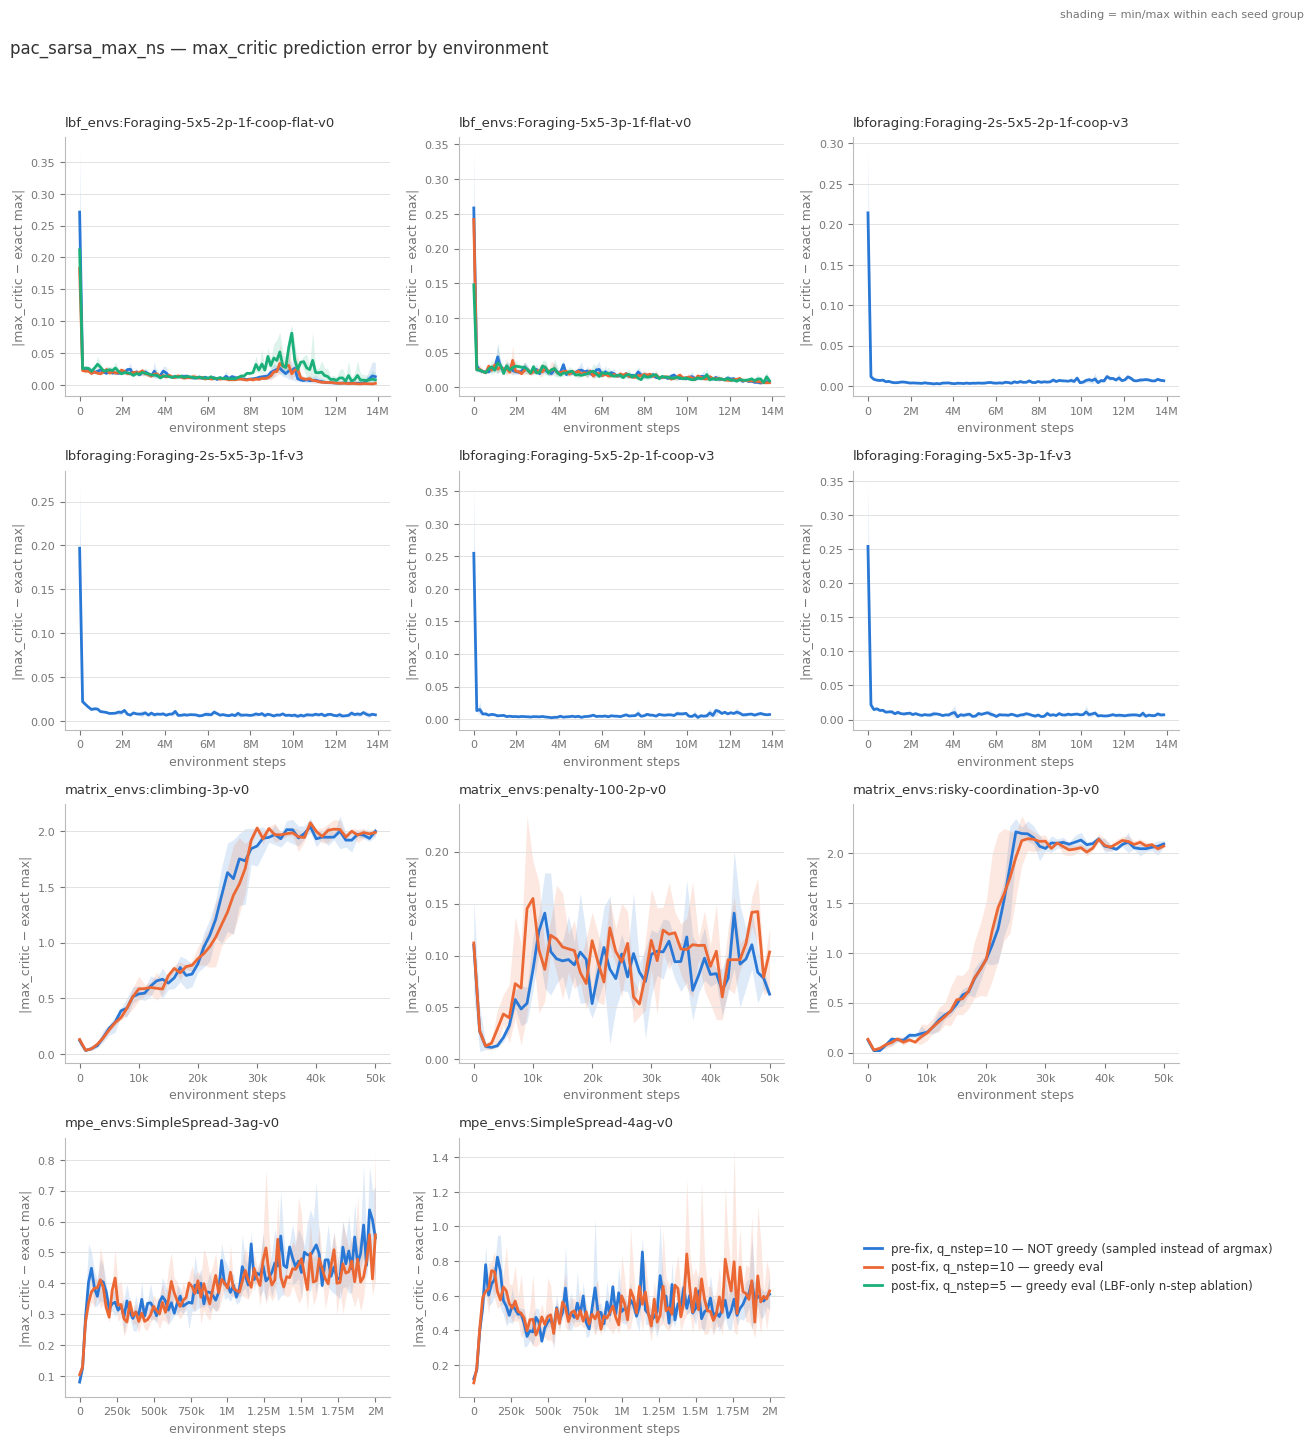

In [6]:
fig, axes = pl.grid(len(envs), ncols=3)
for ax, env in zip(axes, envs):
    pl.panel(mc[mc["env"] == env], y="max_critic_pred_error", hue="group",
             order=GROUP_ORDER, labels=GROUP_LABELS, ax=ax,
             title=env, ylabel="|max_critic − exact max|")
pl.legend(fig, order=GROUP_ORDER, labels=GROUP_LABELS)
pl.finish(fig, suptitle=f"{ALG} — max_critic prediction error by environment",
          note="shading = min/max within each seed group")

End-of-training value of every max-critic diagnostic these runs logged, per
environment and seed group.

In [7]:
lr.final_values(mc, logged, by=("env", "group")).round(4)

max_critic_pred_error  \
                                                                       mean   
env                                      group                                
lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0 post_fix_q10                0.0024   
                                         post_fix_q5                 0.0079   
                                         pre_fix_q10                 0.0129   
lbf_envs:Foraging-5x5-3p-1f-flat-v0      post_fix_q10                0.0068   
                                         post_fix_q5                 0.0092   
                                         pre_fix_q10                 0.0084   
lbforaging:Foraging-2s-5x5-2p-1f-coop-v3 pre_fix_q10                 0.0065   
lbforaging:Foraging-2s-5x5-3p-1f-v3      pre_fix_q10                 0.0067   
lbforaging:Foraging-5x5-2p-1f-coop-v3    pre_fix_q10                 0.0072   
lbforaging:Foraging-5x5-3p-1f-v3         pre_fix_q10                 0.0070   
matrix_envs:climbing-3p-v0               post_fix_q10                1.9867   
                                         pre_fix_q10                 1.9981   
matrix_envs:penalty-100-2p-v0            post_fix_q10                0.1034   
                                         pre_fix_q10                 0.0628   
matrix_envs:risky-coordination-3p-v0     post_fix_q10                2.0717   
                                         pre_fix_q10                 2.0926   
mpe_envs:SimpleSpread-3ag-v0             post_fix_q10                0.5570   
                                         pre_fix_q10                 0.5469   
mpe_envs:SimpleSpread-4ag-v0             post_fix_q10                0.6278   
                                         pre_fix_q10                 0.6094   

                                                              max_critic_loss  \
                                                          std            mean   
env                                      group                                  
lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0 post_fix_q10  0.0018          0.0000   
                                         post_fix_q5   0.0095          0.0004   
                                         pre_fix_q10   0.0191          0.0009   
lbf_envs:Foraging-5x5-3p-1f-flat-v0      post_fix_q10  0.0019          0.0002   
                                         post_fix_q5   0.0038          0.0003   
                                         pre_fix_q10   0.0056          0.0003   
lbforaging:Foraging-2s-5x5-2p-1f-coop-v3 pre_fix_q10   0.0012          0.0001   
lbforaging:Foraging-2s-5x5-3p-1f-v3      pre_fix_q10   0.0007          0.0001   
lbforaging:Foraging-5x5-2p-1f-coop-v3    pre_fix_q10   0.0017          0.0001   
lbforaging:Foraging-5x5-3p-1f-v3         pre_fix_q10   0.0017          0.0001   
matrix_envs:climbing-3p-v0               post_fix_q10  0.0349         11.5836   
                                         pre_fix_q10   0.0440         12.1161   
matrix_envs:penalty-100-2p-v0            post_fix_q10  0.0346          1.0136   
                                         pre_fix_q10   0.0023          0.2122   
matrix_envs:risky-coordination-3p-v0     post_fix_q10  0.0216         27.8667   
                                         pre_fix_q10   0.0312         27.8769   
mpe_envs:SimpleSpread-3ag-v0             post_fix_q10  0.2400          0.5471   
                                         pre_fix_q10   0.1530          0.5831   
mpe_envs:SimpleSpread-4ag-v0             post_fix_q10  0.1042          0.6320   
                                         pre_fix_q10   0.0994          0.5268   

                                                               \
                                                          std   
env                                      group                  
lbf_envs:Foraging-5x5-2p-1f-coop-flat-v0 post_fix_q10  0.0000   
                                         post_fix_q5   0.0006   
                                         pre_fi